In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


In [ ]:
# === CONFIG ===
SITE_ROOT = Path(r"./csv/jennette_north")  # <-- change this
BASELINE_CSV = SITE_ROOT / "baseline2.csv"

REGIME_ROOTS = {
    "onshore_high": SITE_ROOT / "onshore_high",
    "onshore_low": SITE_ROOT / "onshore_low",
    "offshore_high": SITE_ROOT / "offshore_high",
}

N_BASELINE_SAMPLES = 200
MIN_VALID_FRACTION = 0.9  # fraction of frames that must hit a ray for it to be "valid"



In [ ]:
def load_polyline(csv_path: Path, label: str):
    df = pd.read_csv(csv_path)
    df = df[df["label"] == label].sort_values("vertex_index")
    pts = df[["x", "y"]].to_numpy(dtype=float)
    return pts  # shape (N, 2)

def resample_polyline(pts: np.ndarray, n_samples: int = 200):
    # arclength parameterization
    seg = np.diff(pts, axis=0)
    seg_len = np.hypot(seg[:, 0], seg[:, 1])
    s = np.concatenate([[0.0], np.cumsum(seg_len)])
    total = s[-1]
    s_new = np.linspace(0, total, n_samples)

    x = np.interp(s_new, s, pts[:, 0])
    y = np.interp(s_new, s, pts[:, 1])
    return np.stack([x, y], axis=1), s_new  # (n_samples, 2), arclength coord


In [ ]:
baseline_pts_raw = load_polyline(BASELINE_CSV, "baseline")
baseline_pts, baseline_s = resample_polyline(baseline_pts_raw, N_BASELINE_SAMPLES)

print("Baseline raw shape:", baseline_pts_raw.shape)
print("Baseline resampled shape:", baseline_pts.shape)


Baseline raw shape: (2, 2)
Baseline resampled shape: (200, 2)


In [ ]:
def compute_tangents(points: np.ndarray):
    # simple central difference tangents
    d = np.gradient(points, axis=0)
    # normalize
    norms = np.linalg.norm(d, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return d / norms

def rotate90(v: np.ndarray):
    # rotate (+x, +y) -> (-y, +x)
    return np.stack([-v[:, 1], v[:, 0]], axis=1)

def find_any_shoreline_csv(root: Path):
    for path in root.rglob("*.csv"):
        if path.name.lower().endswith(".csv"):
            return path
    return None

def load_shoreline(csv_path: Path):
    df = pd.read_csv(csv_path)
    df = df[df["label"] == "shoreline"].sort_values("vertex_index")
    pts = df[["x", "y"]].to_numpy(dtype=float)
    return pts

# compute baseline tangents + candidate normals
tangents = compute_tangents(baseline_pts)
normals = rotate90(tangents)  # some direction, sign to be fixed

# determine correct sign using one shoreline example
example_csv = find_any_shoreline_csv(SITE_ROOT)  # Changed from DATA_ROOT to SITE_ROOT
if example_csv is None:
    raise RuntimeError("No shoreline CSV found under SITE_ROOT")

shore_example = load_shoreline(example_csv)
baseline_center = baseline_pts.mean(axis=0)
shore_center = shore_example.mean(axis=0)
vec_land_to_sea = shore_center - baseline_center  # rough direction

# average dot product to decide whether to flip normals
dot = np.mean(np.sum(normals * vec_land_to_sea, axis=1))
if dot < 0:
    normals = -normals  # flip to point offshore

print("Normals computed, dot sign:", "offshore OK" if dot >= 0 else "flipped to offshore")


Normals computed, dot sign: flipped to offshore


C:\Users\monaz\AppData\Local\Temp\ipykernel_38176\3370641988.py:36: RuntimeWarning: Mean of empty slice.
  shore_center = shore_example.mean(axis=0)
c:\Users\monaz\miniforge3\envs\sam2_realtime_env\lib\site-packages\numpy\_core\_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


In [ ]:
def intersect_ray_with_segment(o, d, a, b, eps=1e-9):
    """
    Ray: o + t*d, t >= 0
    Segment: a + u*(b-a), 0 <= u <= 1
    Returns t (distance along ray) and u if they intersect, else None.
    """
    o = np.asarray(o, dtype=float)
    d = np.asarray(d, dtype=float)
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    v = b - a
    M = np.column_stack((d, -v))
    det = np.linalg.det(M)
    if abs(det) < eps:
        return None

    t, u = np.linalg.solve(M, a - o)
    if t >= -eps and -eps <= u <= 1 + eps:
        return float(t), float(u)
    return None

def compute_distances_for_shoreline(
    baseline_pts: np.ndarray,
    normals: np.ndarray,
    shoreline_pts: np.ndarray,
):
    """
    For each baseline point + normal, find nearest intersection with shoreline polyline.
    Returns array of length N_BASELINE_SAMPLES with distance t (>=0) or np.nan if no hit.
    """
    n_base = baseline_pts.shape[0]
    dists = np.full(n_base, np.nan, dtype=float)

    # precompute segments for shoreline
    seg_start = shoreline_pts[:-1]
    seg_end = shoreline_pts[1:]
    n_seg = seg_start.shape[0]

    for i in range(n_base):
        o = baseline_pts[i]
        d = normals[i]
        best_t = None

        for j in range(n_seg):
            res = intersect_ray_with_segment(o, d, seg_start[j], seg_end[j])
            if res is None:
                continue
            t, u = res
            if t < 0:
                continue
            if best_t is None or t < best_t:
                best_t = t

        if best_t is not None:
            dists[i] = best_t

    return dists

In [ ]:
def list_subfolders(root: Path):
    return sorted([p for p in root.iterdir() if p.is_dir()])

def list_shoreline_csvs(folder: Path):
    # one shoreline per CSV
    return sorted(folder.glob("*.csv"))

# Process all regime folders and collect their subfolders
all_subfolders = []
for regime_name, regime_root in REGIME_ROOTS.items():
    subfolders = list_subfolders(regime_root)
    all_subfolders.extend(subfolders)
    print(f"Found {len(subfolders)} subfolders under {regime_name}")
    for sf in subfolders:
        print(f"  - {sf.name}")

subfolders = all_subfolders


Found 6 subfolders under onshore_high
  - 10
  - 11
  - 12
  - 13
  - 8
  - 9
Found 6 subfolders under onshore_low
  - 11
  - 13
  - 15
  - 17
  - 7
  - 9
Found 6 subfolders under offshore_high
  - 11
  - 12
  - 13
  - 14
  - 15
  - 16


In [ ]:
def build_curves_for_folder(folder: Path,
                            baseline_pts: np.ndarray,
                            normals: np.ndarray):
    csv_paths = list_shoreline_csvs(folder)
    curves = []

    for path in csv_paths:
        shoreline_pts = load_shoreline(path)
        dists = compute_distances_for_shoreline(baseline_pts, normals, shoreline_pts)
        curves.append(dists)

    if not curves:
        return None, []

    curves = np.stack(curves, axis=0)  # (n_frames, n_baseline_samples)
    return curves, csv_paths

def plot_spaghetti_for_folder(folder: Path,
                              baseline_s: np.ndarray,
                              curves: np.ndarray,
                              max_curves_to_plot: int = None):
    """
    baseline_s: arclength coords of baseline (same length as curves.shape[1])
    curves: (n_frames, n_samples)
    """
    n_frames, n_samples = curves.shape
    if max_curves_to_plot is not None:
        n_plot = min(n_frames, max_curves_to_plot)
        idx = np.linspace(0, n_frames - 1, n_plot, dtype=int)
        curves_to_plot = curves[idx]
    else:
        curves_to_plot = curves

    plt.figure(figsize=(8, 4))
    s_norm = (baseline_s - baseline_s.min()) / (baseline_s.max() - baseline_s.min())
    for c in curves_to_plot:
        plt.plot(s_norm, c, alpha=0.2)

    plt.xlabel("Alongshore (normalized baseline coordinate)")
    plt.ylabel("Distance offshore (pixels along normal)")
    plt.title(f"Spaghetti plot – {folder.name} ({curves.shape[0]} frames)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_raw_geometry_spaghetti(folder: Path,
                                baseline_raw: np.ndarray,
                                max_shorelines_to_plot: int = 300,
                                jump_thresh: float = 50):
    """
    jump_thresh: max allowed pixel distance between consecutive shoreline points.
    Larger jumps are skipped, preventing fake end-to-end connections.
    """
    csv_paths = list_shoreline_csvs(folder)
    if len(csv_paths) == 0:
        print(f"[{folder.name}] No CSVs found.")
        return

    if max_shorelines_to_plot is not None:
        csv_paths = csv_paths[:max_shorelines_to_plot]

    plt.figure(figsize=(7, 7))

    plt.plot(
        baseline_raw[:,0], baseline_raw[:,1],
        color="red", linewidth=3, label="Baseline"
    )

    for path in csv_paths:
        shoreline_pts = load_shoreline(path)
        if shoreline_pts.shape[0] < 2:
            continue

        x, y = shoreline_pts[:,0], shoreline_pts[:,1]
        dx = np.diff(x)
        dy = np.diff(y)
        dist = np.hypot(dx, dy)

        # break where jumps are too large
        breaks = np.where(dist > jump_thresh)[0]

        start = 0
        for b in breaks:
            plt.plot(x[start:b+1], y[start:b+1], linewidth=0.6, alpha=0.25)
            start = b+1

        # last chunk
        plt.plot(x[start:], y[start:], linewidth=0.6, alpha=0.25)

    plt.gca().invert_yaxis()
    plt.title(f"Raw Geometry – {folder.name} ({len(csv_paths)} frames)")
    plt.xlabel("Pixel X")
    plt.ylabel("Pixel Y")
    plt.grid(True)
    plt.legend(loc="upper left", framealpha=0.7)
    plt.tight_layout()
    plt.show()


Plotting raw geometry for folder: 10


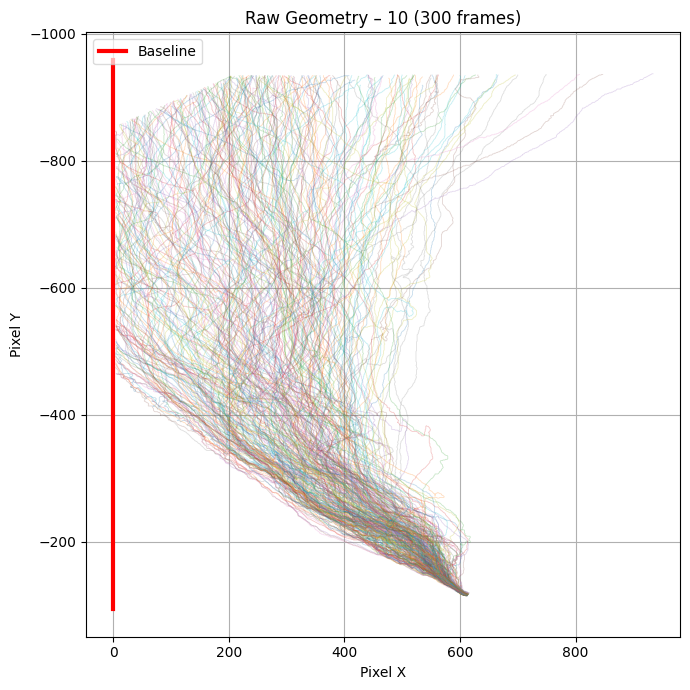

Plotting raw geometry for folder: 11


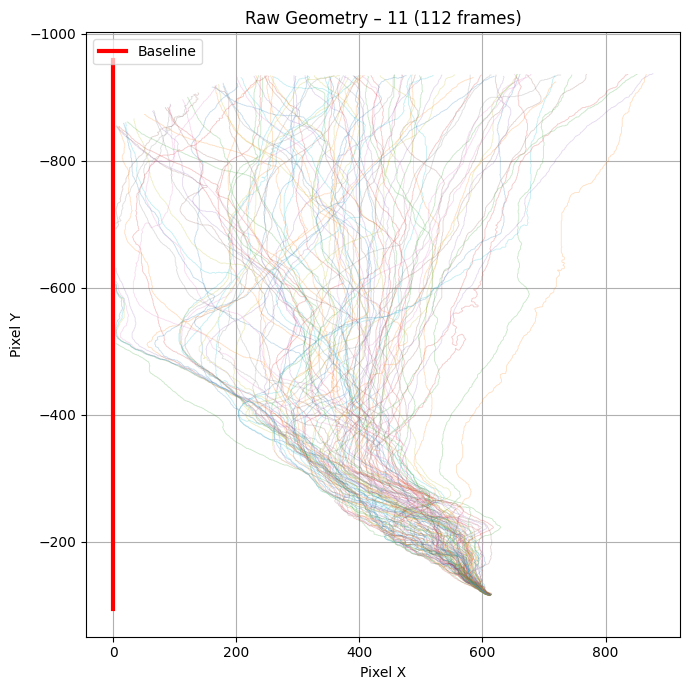

Plotting raw geometry for folder: 12


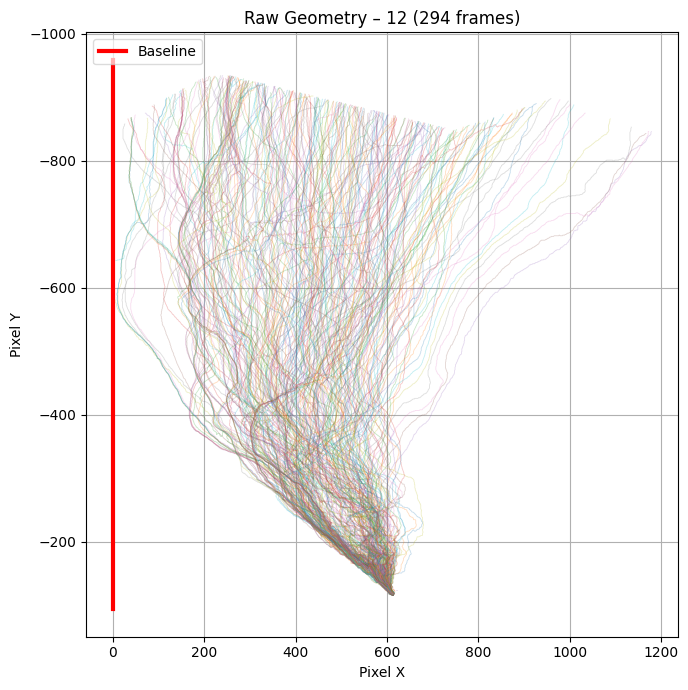

Plotting raw geometry for folder: 13


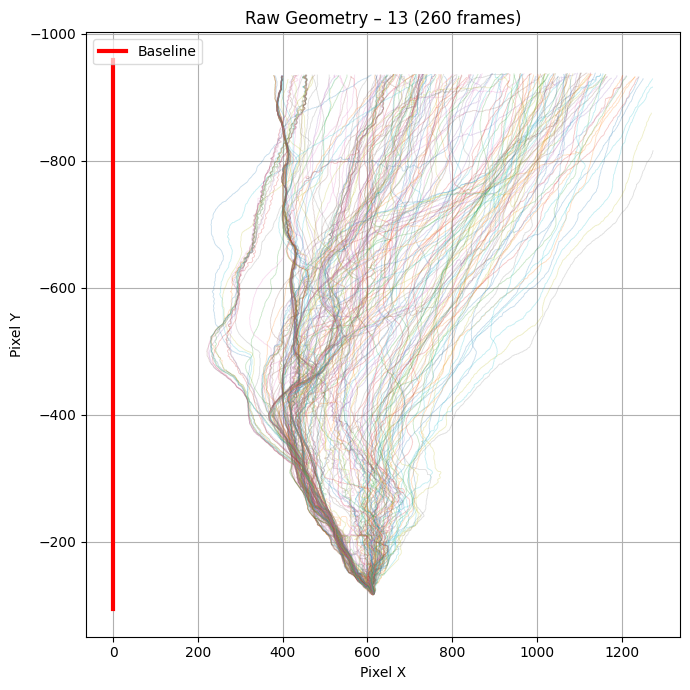

Plotting raw geometry for folder: 8


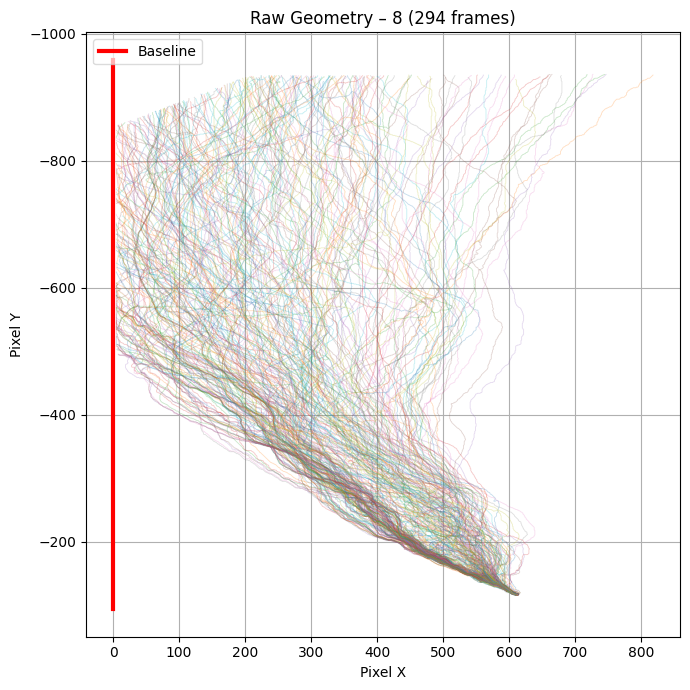

Plotting raw geometry for folder: 9


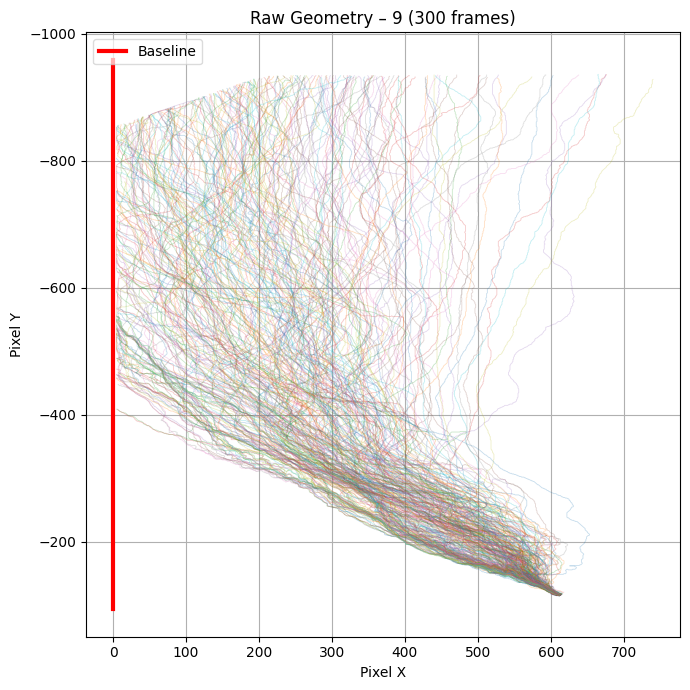

Plotting raw geometry for folder: 11


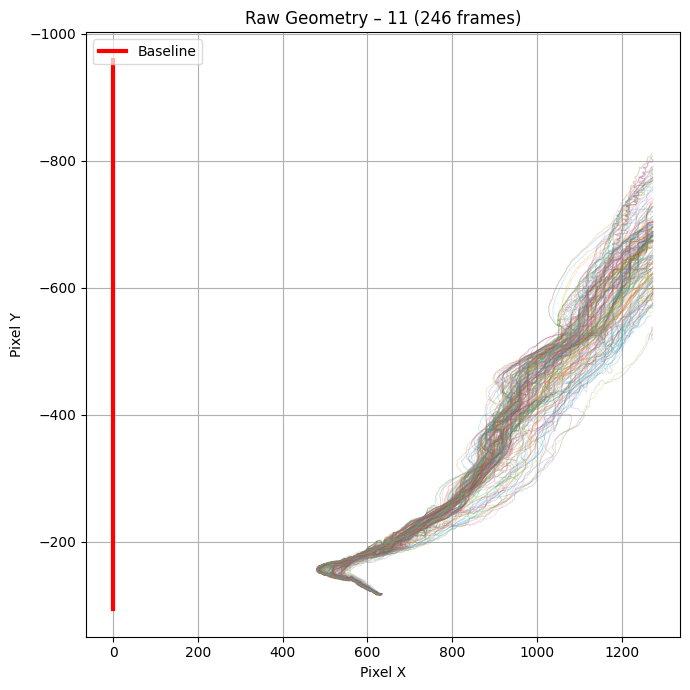

Plotting raw geometry for folder: 13


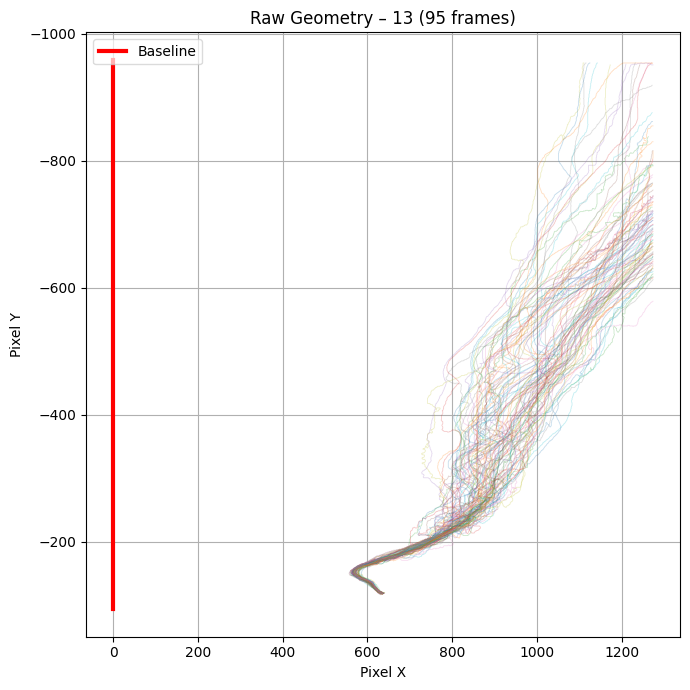

Plotting raw geometry for folder: 15


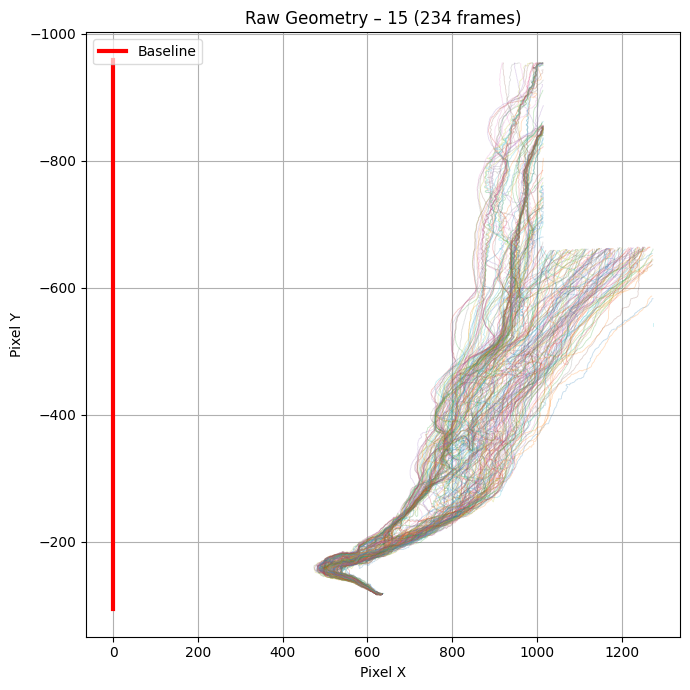

Plotting raw geometry for folder: 17


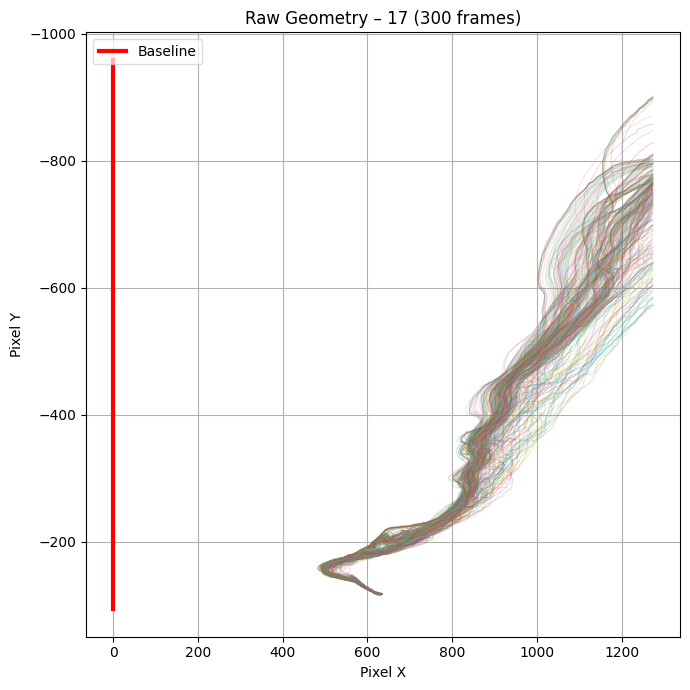

Plotting raw geometry for folder: 7


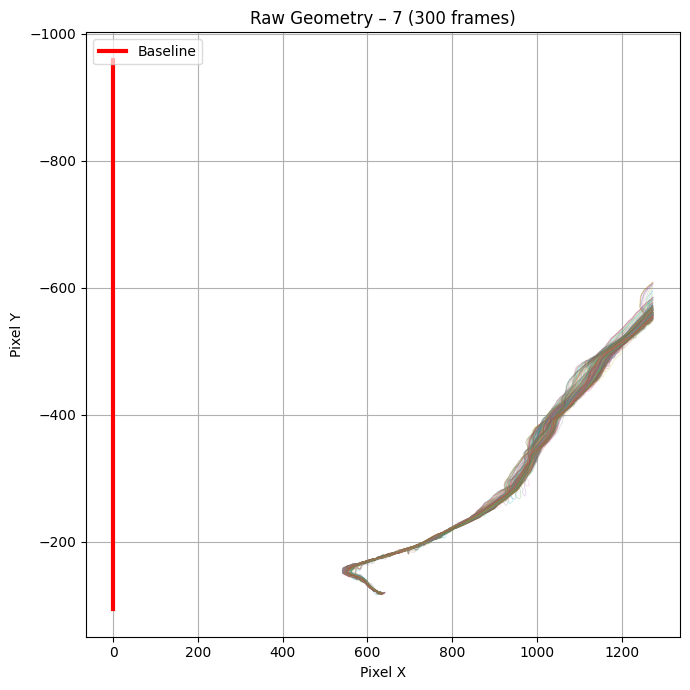

Plotting raw geometry for folder: 9


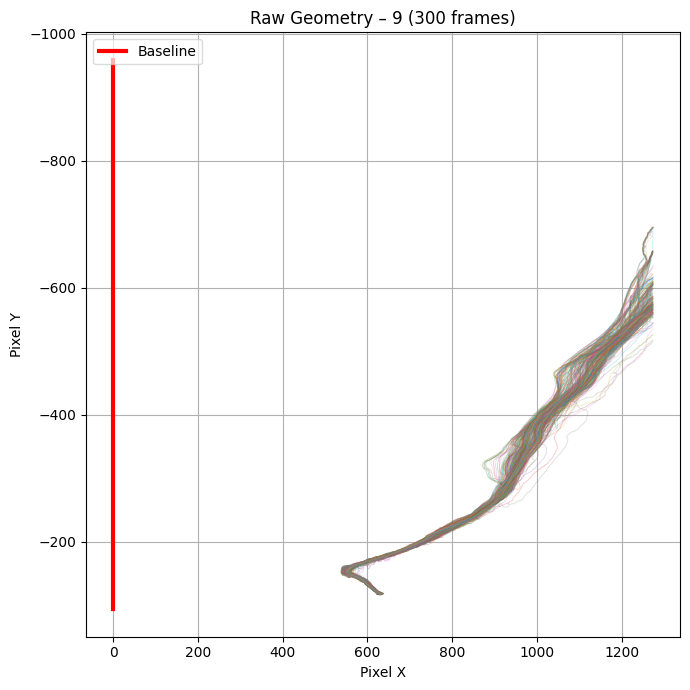

Plotting raw geometry for folder: 11


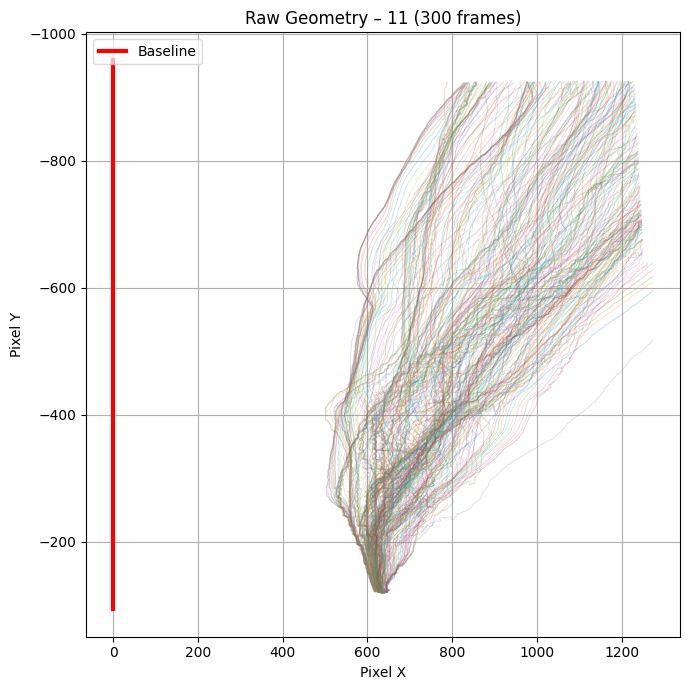

Plotting raw geometry for folder: 12


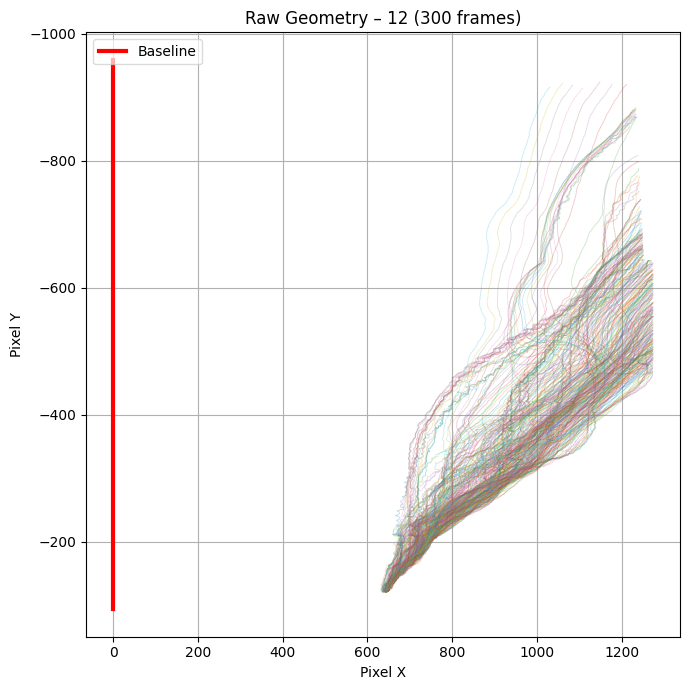

Plotting raw geometry for folder: 13


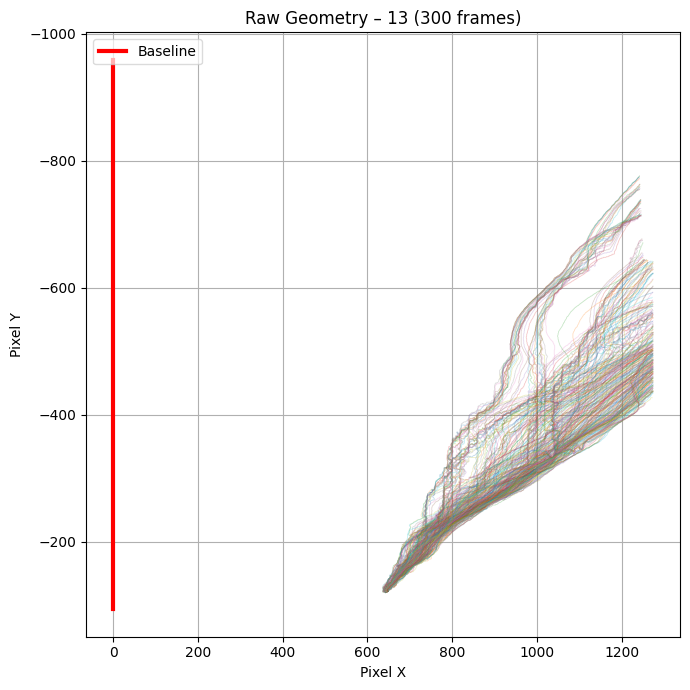

Plotting raw geometry for folder: 14


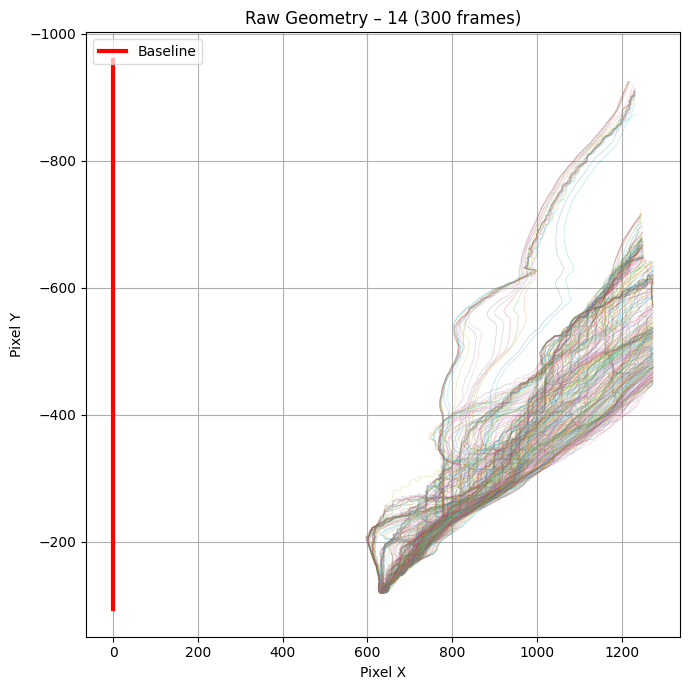

Plotting raw geometry for folder: 15


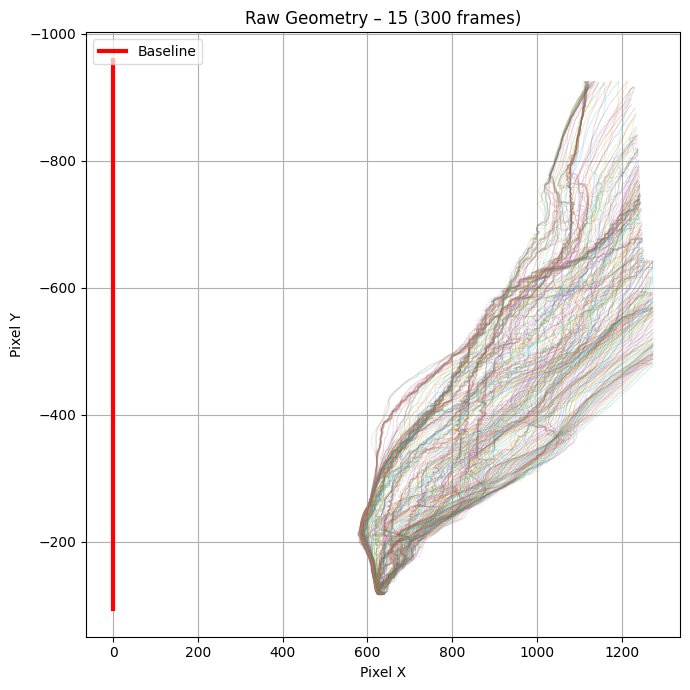

Plotting raw geometry for folder: 16


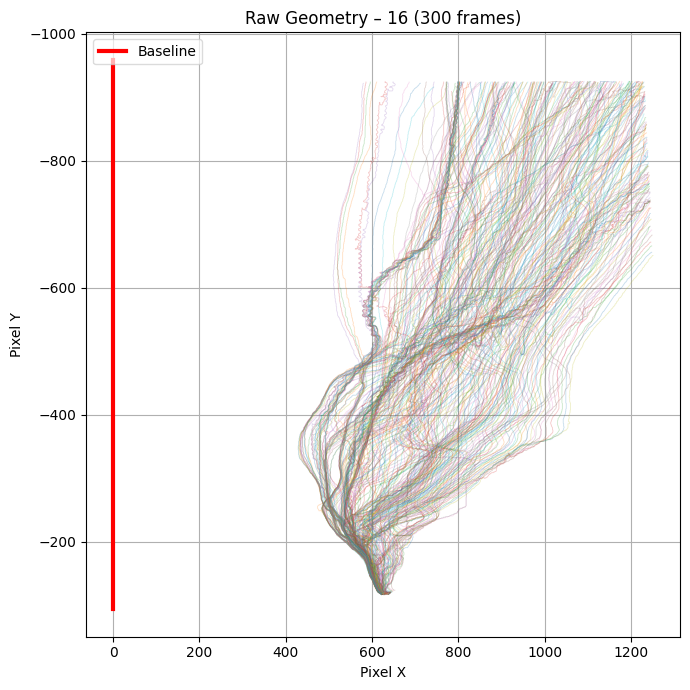

In [ ]:
for sf in subfolders:
    print(f"Plotting raw geometry for folder: {sf.name}")
    plot_raw_geometry_spaghetti(sf, baseline_pts_raw)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

def plot_raw_geometry_spaghetti_on_frame(
    folder: Path,
    baseline_raw: np.ndarray,
    frame_png_path: str,                 # <-- add this
    max_shorelines_to_plot: int = 300,
    jump_thresh: float = 50,
    alpha: float = 0.20,
    lw: float = 0.7
):
    """
    Overlay spaghetti shorelines + baseline on top of a reference frame image.

    Assumes shoreline CSV coordinates use x in image pixels and y stored as negative
    (so y_img = -y_raw). Axis limits are locked to the image dimensions.
    """
    csv_paths = list_shoreline_csvs(folder)
    if len(csv_paths) == 0:
        print(f"[{folder.name}] No CSVs found.")
        return

    if max_shorelines_to_plot is not None:
        csv_paths = csv_paths[:max_shorelines_to_plot]

    # --- load background frame ---
    img = mpimg.imread(frame_png_path)
    h, w = img.shape[:2]

    plt.figure(figsize=(10, 6))
    plt.imshow(img, origin="upper")

    # --- baseline (convert y) ---
    bx = baseline_raw[:, 0]
    by = -baseline_raw[:, 1]
    plt.plot(bx, by, color="red", linewidth=3, label="Baseline")

    # --- spaghetti shorelines ---
    for path in csv_paths:
        shoreline_pts = load_shoreline(path)
        if shoreline_pts.shape[0] < 2:
            continue

        x = shoreline_pts[:, 0]
        y = -shoreline_pts[:, 1]  # key conversion

        dx = np.diff(x)
        dy = np.diff(y)
        dist = np.hypot(dx, dy)

        breaks = np.where(dist > jump_thresh)[0]

        start = 0
        for b in breaks:
            plt.plot(x[start:b+1], y[start:b+1], linewidth=lw, alpha=alpha)
            start = b + 1

        plt.plot(x[start:], y[start:], linewidth=lw, alpha=alpha)

    # --- lock axes to image bounds (prevents "image under plot") ---
    plt.xlim(0, w)
    plt.ylim(h, 0)

    #plt.title(f"Shoreline ensemble (spaghetti) overlaid on frame – folder {folder.name} ({len(csv_paths)} frames)")
    plt.title(f"Shoreline ensemble (spaghetti) overlaid on frame ({len(csv_paths)} frames)")
    plt.xlabel("Pixel X")
    plt.ylabel("Pixel Y")

    # optional: turn off grid for cleaner paper-style look
    # plt.grid(False)

    plt.legend(loc="upper left", framealpha=0.8)
    plt.tight_layout()
    plt.show()


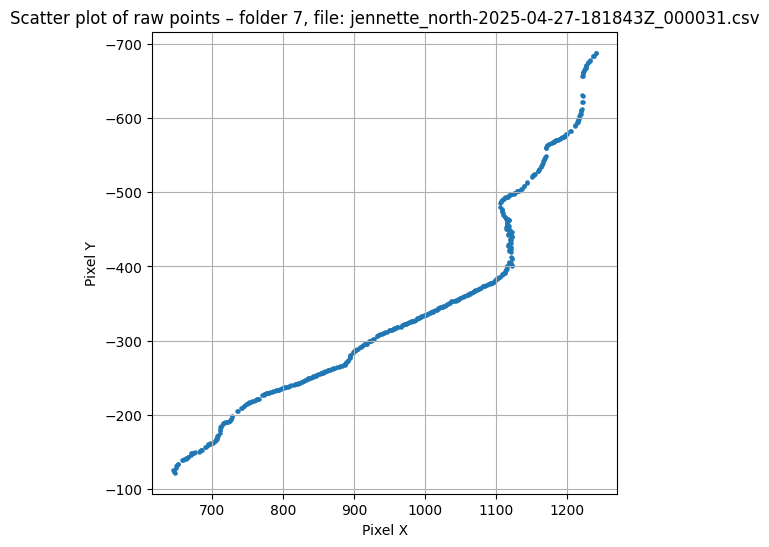

In [ ]:
# --- Debug one shoreline from a specific folder (e.g., folder "7") ---
folder_14 = [sf for sf in subfolders if sf.name == "14"][0]
csv_paths = list_shoreline_csvs(folder_14)

# Pick the first shoreline CSV
test_csv = csv_paths[0]
shore = load_shoreline(test_csv)

plt.figure(figsize=(6, 6))
plt.scatter(shore[:,0], shore[:,1], s=5)
plt.gca().invert_yaxis()
plt.title(f"Scatter plot of raw points – folder 7, file: {test_csv.name}")
plt.xlabel("Pixel X")
plt.ylabel("Pixel Y")
plt.grid(True)
plt.show()


In [ ]:
print("image (h,w):", h, w)
print("shore x range:", shore[:,0].min(), shore[:,0].max())
print("shore y range:", shore[:,1].min(), shore[:,1].max())


image (h,w): 960 1280
shore x range: 572.0 1274.0
shore y range: -563.0 -119.0


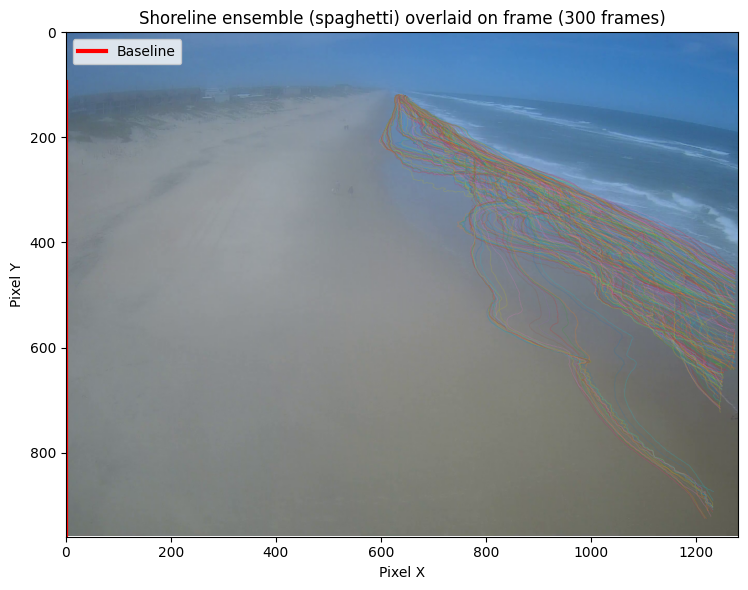

: 

In [ ]:
plot_raw_geometry_spaghetti_on_frame(
    folder_14,
    baseline_raw=baseline_pts_raw,
    frame_png_path="./jennette_pier/14/jennette_north-2025-04-27-181843Z_000031.png",
    max_shorelines_to_plot=300
)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

img_path = "./jennette_pier/14/jennette_north-2025-04-27-181843Z_000031.png"  # <-- change this
img = mpimg.imread(img_path)
h, w = img.shape[:2]

x = shore[:, 0]
y = -shore[:, 1]   # <-- the key fix

plt.figure(figsize=(10, 6))
plt.imshow(img, origin="upper")

# use plot for a cleaner shoreline than scatter
plt.plot(x, y, linewidth=2)

# lock axes to image bounds so the image fills the plot
plt.xlim(0, w)
plt.ylim(h, 0)

plt.title(f"Shoreline overlaid on frame")
plt.xlabel("Pixel X")
plt.ylabel("Pixel Y")
plt.tight_layout()
plt.show()
